In [13]:
from Parts.imports import *
from Parts.data_loader import DatasetLoader, DatasetLoaderV2
from Parts.models import U_NET_VANILLA, U_NET_RESNET, U_NET_RESNET_ATTENTION, U_NET_PLUS_PLUS, TRANS_U_NET
from Parts.training_loop import TrainingLoop, TrainingLoopAdvanced, SaveState, EarlyStopping
from Parts.losses import DiceLoss, Mixed_Dice_Sigmoid, IntersectionOverUnion
import tqdm

DEBUG = False

In [14]:
PATH_TO_SAVED = r"model_weights/U_NET_VANILLA.torch"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

df = torch.load(f=PATH_TO_SAVED, map_location=DEVICE)

In [15]:
model = U_NET_VANILLA()
model_weights = df['model_state_dict']
optim_weights = df['optimizer_state_dict']

model.load_state_dict(state_dict=model_weights)

<All keys matched successfully>

In [16]:
loss_mixed = Mixed_Dice_Sigmoid()
loss_dice = DiceLoss()
loss_iou = IntersectionOverUnion()

In [17]:
data_test = r"C:\Users\itizs\Downloads\archive(1)\brisc2025\segmentation_task\test\images"
label_test = r"C:\Users\itizs\Downloads\archive(1)\brisc2025\segmentation_task\test\masks"
test_data = DatasetLoaderV2(data_dir=data_test, label_dir=label_test, dim=(256, 256), transformations=None)
test_data_loader = DataLoader(dataset=test_data, batch_size=8, shuffle=False, num_workers=0)

In [18]:
model.to(DEVICE)
model.eval()

U_NET_VANILLA(
  (layers): ModuleDict(
    (encoder_0): U_NET_VANILLA_ENCODER(
      (downsample): Common_Module_BN(
        (conv): Sequential(
          (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (decoder_0): U_NET_VANILLA_DECODER(
      (upsample): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (pipe): Common_Module_BN(
        (conv): Sequential(
          (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

In [19]:
records = []
with torch.no_grad():
    bar = tqdm.tqdm(total= len(test_data_loader))
    for i, (image, label) in enumerate(test_data_loader):
        if i == 25:
            break
        # image.unsqueeze(0)
        # label.unsqueeze(0)
        image.to(DEVICE)
        label.to(DEVICE)
        
        prediction = model(image)

        dice = loss_dice(label, prediction)
        iou = loss_iou(label, prediction)
        mix = loss_mixed(label, prediction)
        records.append({ 'index' : i, 
                    'dice_loss' : dice.item(),
                    # 'iou_loss' : iou.item(),
                    'mix_loss' : mix.item()})
        bar.update(1)
record = pandas.DataFrame(records)

 23%|██▎       | 25/108 [10:47:12<35:48:44, 1553.31s/it]


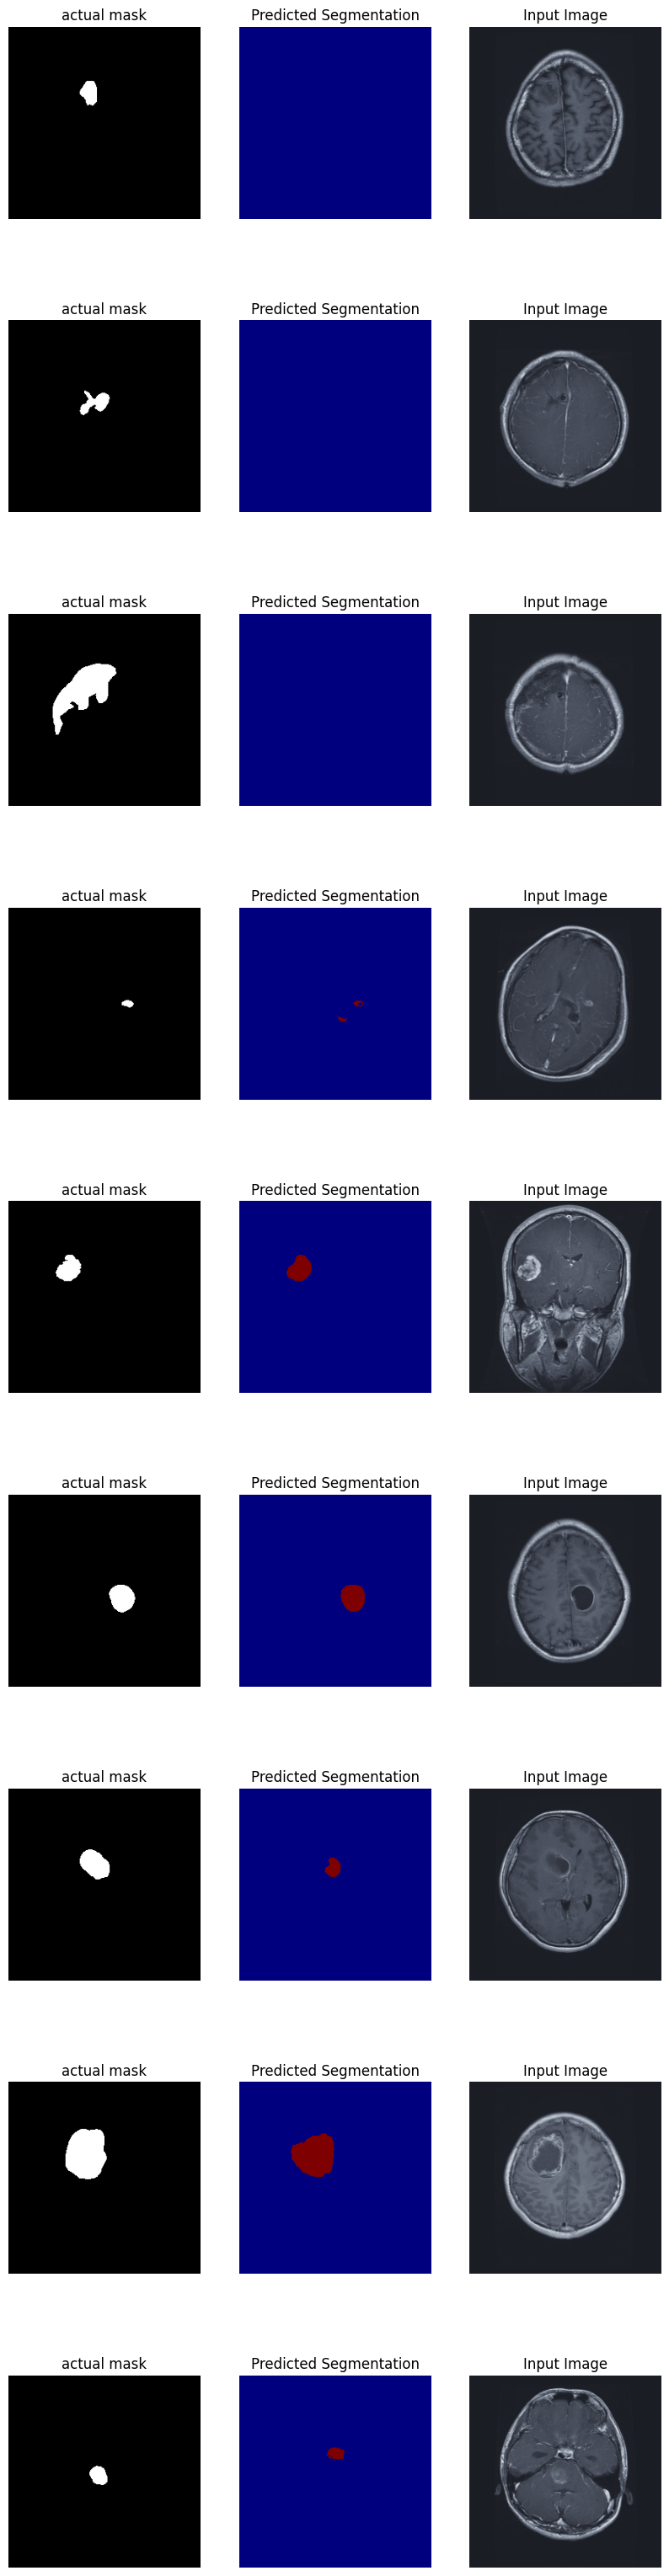

In [20]:
def show(start, samples, dataloader):
    fig, axes = plt.subplots(9, 3, figsize=(10, 40))
    for count in range(start, start + samples):
    
        image, label = dataloader[count]
        image = image.unsqueeze(0) # need batch dim
        image.to(DEVICE)
        label.to(DEVICE)

        prediction = model(image)

        dice = loss_dice(label, prediction)
        iou = loss_iou(label, prediction)
        mix = loss_mixed(label, prediction)

        prediction = (prediction.sigmoid().detach().cpu().squeeze().numpy() > 0.5)

        axes[count%samples][0].imshow(label.squeeze(), cmap='gray')
        axes[count%samples][0].set_title("actual mask")
        axes[count%samples][0].axis('off')

        axes[count%samples][1].imshow(prediction, cmap='jet')
        axes[count%samples][1].set_title("Predicted Segmentation")
        axes[count%samples][1].axis('off')

        axes[count%samples][2].imshow(image.detach().cpu().squeeze().sigmoid().numpy().transpose(1, 2, 0))
        axes[count%samples][2].set_title("Input Image")
        axes[count%samples][2].axis('off')

show(77, 9, test_data)

In [21]:
record

,index,dice_loss,mix_loss
0,0,0.411898,0.223165
1,1,0.769476,0.431899
2,2,0.289299,0.168842
3,3,0.716092,0.411407
4,4,0.196518,0.115880
5,5,0.909394,0.550101
6,6,0.961237,0.542436
7,7,0.533471,0.305599
8,8,0.527020,0.298497
9,9,0.408770,0.248098
